# Set Up

## Package

In [1]:
import nidaqmx
from nidaqmx.constants import AcquisitionType, Level, Edge
import numpy as np
from contextlib import ExitStack
import time
import pyvisa
from Equipments import SR400
from Equipments import Weeder
import matplotlib.pyplot as plt

## Initialize

In [2]:
rm = pyvisa.ResourceManager()
print(rm.list_resources())

('ASRL1::INSTR', 'ASRL2::INSTR', 'ASRL3::INSTR', 'ASRL4::INSTR', 'ASRL5::INSTR', 'ASRL6::INSTR', 'ASRL7::INSTR', 'GPIB0::23::INSTR')


In [3]:
sr400 = SR400.SR400('GPIB0::23::INSTR')

In [4]:
weeder = Weeder.Weeder("ASRL1::INSTR")

In [11]:
weeder.move(header = "A" , position = 1020)

'AM1010'

In [8]:
weeder.save(header = "A",more = True)

'saving complete.'

## Functions

# Experiments

## Photon Counting

## Rydberg Spectroscopy

In [30]:
# initialize the phton counter
sr400.counter_set(count_mode = "INDEPENDENT", count_preset = 1, count_period_num=10, dwell= 6,sourceA="INPUT1",sourceB="INPUT2", gate_A_mode="FIXED", gate_A_delay=500e-3,
                gate_A_width=500e-3,gate_B_mode="CW")

The photon counter is now set to:

Counting Mode: INDEPENDENT 
T Input: TRIG
T Preset: 1E0
Period number: 10
Dwell time: 6E0
Counter A source: INPUT1
Counter B source: INPUT2

The gate A is set to:

Delay: 500.0E-3
Width: 500.0E-3


The gate B is set to: CW


In [31]:
freq_step = 78.5 #KHz
motor_step_range = np.arange(0,101)
relative_freq_range = freq_step * motor_step_range
photon_num_list = []

In [50]:
# set the sequence
# MOT is controlled by the PFI8 which is ctr8 but using digital output instead of RF
pulse_arrangement = [["ctr0", 1e-6, 4e-6], # 480 EXC
                     ["ctr1", 1e-6, 4e-6], # 780 EXC
                     ["ctr2", 29e-6, 70e-6], # SR400 trigger, only use the rising edge
                    ]
repeat = 100
# time.sleep(5)
starttot = time.time()
for step in motor_step_range:
    start = time.time()
    for i in range(repeat):
        with ExitStack() as stack:
            # initialize the trigger, the trigger signal here is also used for the MOT, the following the sequence is triggered by the falling edge of the MOT
            trigger_src = "/Dev1/PFI8"
            task_trigger_MOT = stack.enter_context(nidaqmx.Task())
            task_trigger_MOT.do_channels.add_do_chan(lines="Dev1/port0/line8")
            tasks = [task_trigger_MOT]
        
            # initialize the sequence
            counter_names = [row[0] for row in pulse_arrangement]
            # print(counter_names)
            for idn, name in enumerate(counter_names):
                task = stack.enter_context(nidaqmx.Task())
                task.co_channels.add_co_pulse_chan_time(f"Dev1/{name}",idle_state=Level.LOW, initial_delay = pulse_arrangement[idn][1],
                                                        high_time=pulse_arrangement[idn][2],low_time=pulse_arrangement[idn][2])
                task.timing.cfg_implicit_timing(sample_mode = AcquisitionType.FINITE,samps_per_chan=1)
                task.triggers.start_trigger.cfg_dig_edge_start_trig(trigger_source=trigger_src,trigger_edge=Edge.FALLING)
                tasks.append(task)
        
            # arm the sequence
            for task in tasks:
                task.start()
        
            # input("Counters armed. Press enter to start pulsing.\n")
            
            # trigger the sequence
            task_trigger_MOT.write(True)
            # time.sleep(1)
            task_trigger_MOT.write(False)
            
            # experiment start here
            # photon_num = sr400.read_count(counter="A")
            photon_num_list.append(sr400.read_count(counter="A"))
    end = time.time()
    duration = end-start
    print(duration)
    weeder.step(header="A",direction="+")
            # experiment end

endtot = time.time()
print(endtot-starttot)

1.134599208831787
1.059112310409546
1.12910795211792
1.0376577377319336
1.0632836818695068
1.0307910442352295
1.0352344512939453
1.1342132091522217
1.0333971977233887
1.0200700759887695
1.1085405349731445
1.1223738193511963
1.0958137512207031
1.076024055480957
1.1554040908813477
1.0941755771636963
1.1858370304107666
1.0576610565185547
1.140392541885376
1.156674861907959
1.0550391674041748
1.2026422023773193
1.1648890972137451
1.0391905307769775
1.2568624019622803
1.2218008041381836
1.084984540939331
1.1695411205291748
1.1295185089111328
1.1534383296966553
1.0539674758911133
1.0608601570129395
1.0788898468017578
1.0338783264160156
1.0791668891906738
1.0816333293914795
1.0273151397705078
1.1016287803649902
1.118300437927246
1.3103346824645996
1.0830748081207275
1.196434736251831
1.0391426086425781
1.066683292388916
1.0603549480438232
0.9826860427856445
1.0851871967315674
1.0878024101257324
0.9987297058105469
1.0970659255981445
1.1914925575256348
1.1264433860778809
1.186112403869629
1.111

In [ ]:
# set the internal cycle
# set the sequence
pulse_arrangement = [["ctr0", 0, 9.484e-3] # MOT
                     ["ctr1", 1e-6, 4e-6], # 480 EXC
                     ["ctr2", 1e-6, 4e-6], # 780 EXC
                     ["ctr3", 29e-6, 70e-6], # SR400 trigger, only use the rising edge
                    ]
T = pulse_arrangement[0][2]-0.1e-6
# T = pulse_arrangement[0][2] + pulse_arrangement[1][1] + pulse_arrangement[1][2] + 200e-6
start2 = time.time()
with ExitStack() as stack:
    # initialize the global clock
    Clock_trigger = stack.enter_context(nidaqmx.Task())
    Clock_trigger.do_channels.add_do_chan(lines="Dev1/port0/line0")
    Clock = stack.enter_context(nidaqmx.Task())
    Clock.co_channels.add_co_pulse_chan_time("Dev1/ctr7", idle_state=Level.LOW, initial_delay = 0,high_time=T/2,low_time=T/2)
    Clock.timing.cfg_implicit_timing(sample_mode=AcquisitionType.CONTINUOUS)
    Clock.triggers.start_trigger.cfg_dig_edge_start_trig(trigger_source="/Dev1/PFI0", trigger_edge=Edge.RISING)
    tasks = [Clock, Clock_trigger]

    # initialize the sequence
    trigger_src = "/Dev1/PFI8"
    counter_names = [row[0] for row in pulse_arrangement]
    print(counter_names)
    for idn, name in enumerate(counter_names):
        task = stack.enter_context(nidaqmx.Task())
        task.co_channels.add_co_pulse_chan_time(f"Dev1/{name}",idle_state=Level.LOW, initial_delay = pulse_arrangement[idn][1],
                                                high_time=pulse_arrangement[idn][2],low_time=pulse_arrangement[idn][2])
        task.timing.cfg_implicit_timing(sample_mode = AcquisitionType.FINITE,samps_per_chan=1)
        task.triggers.start_trigger.cfg_dig_edge_start_trig(trigger_source=trigger_src,trigger_edge=Edge.RISING)
        task.triggers.start_trigger.retriggerable = True
        tasks.append(task)

    # arm the sequence
    for task in tasks:
        task.start()

    # input("Counters armed. Press enter to start pulsing.\n")
    
    # trigger the sequence
    Clock_trigger.write(True)
    Clock_trigger.write(False)
    input("Press enter to stop pulsing.\n")
    # experiment start here
    weeder.step(header="A",direction="+")
    # photon_num = sr400.read_count(counter="A")
    photon_num_list.append(sr400.read_count(counter="A"))
    # experiment end
end2 = time.time()
print(end2-start2)
        

['ctr0']


In [7]:
T=1e-3
Clock_trigger = nidaqmx.Task()
Clock_trigger.do_channels.add_do_chan(lines="Dev1/port0/line0")
Clock = nidaqmx.Task()
Clock.co_channels.add_co_pulse_chan_time("Dev1/ctr7", idle_state=Level.LOW, initial_delay = 0,high_time=T/2,low_time=T/2)
Clock.timing.cfg_implicit_timing(sample_mode=AcquisitionType.CONTINUOUS)
Clock.triggers.start_trigger.cfg_dig_edge_start_trig(trigger_source="/Dev1/PFI0", trigger_edge=Edge.RISING)
Clock.start()

task = nidaqmx.Task()
task.co_channels.add_co_pulse_chan_time("Dev1/ctr0",idle_state=Level.LOW, initial_delay = 0,high_time=1e-3/2,low_time=1e-3/2)
task.timing.cfg_implicit_timing(sample_mode = AcquisitionType.FINITE,samps_per_chan=1)
task.triggers.start_trigger.cfg_dig_edge_start_trig(trigger_source="/Dev1/PFI8",trigger_edge=Edge.RISING)
task.triggers.start_trigger.retriggerable = True
task.start()

Clock_trigger.start()
Clock_trigger.write(True)
Clock_trigger.write(False)
input("Press enter to stop pulsing.\n")
Clock.close()
Clock_trigger.close()
task.close()

Press enter to stop pulsing.
 


In [25]:
x = np.linspace(1,5,5)
y = np.linspace(5,8,5)

Text(0, 0.5, 'Intensity(a.u.)')

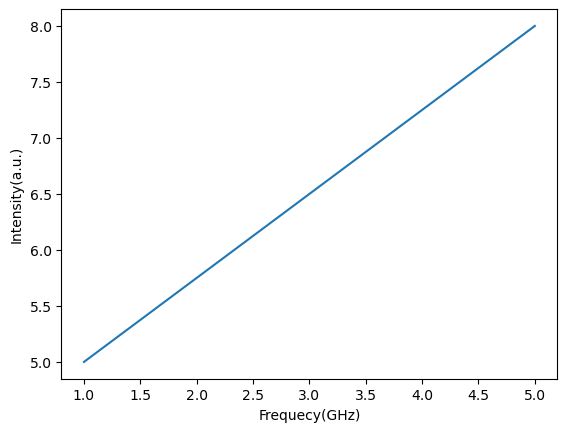

In [29]:
fig, ax = plt.subplots()
# ax.plot(relative_freq_range,array(photon_num_list))
ax.plot(x,y)
ax.set_xlabel("Frequecy(KHz)")
ax.set_ylabel("Intensity(a.u.)")

## Shadow Imagining

# Debug

## Detect the devices and terminals

In [ ]:
devices = nidaqmx.system.System.local().devices
print([device.name for device in devices])
# print(nidaqmx.system.System.local().devices)

In [ ]:
for device in nidaqmx.system.System.local().devices:
    print(f"Device: {device.name}")
    
    # Analog Input Channels
    print("  AI Channels:", list(device.ai_physical_chans))

    # Analog Output Channels
    print("  AO Channels:", list(device.ao_physical_chans))
    
    # Digital Input Channels
    print("  DI Channels:", list(device.di_lines))

    # Digital Output Channels
    print("  DO Channels:", list(device.do_lines))

    # Counter Output Channels
    print(" CO Channels:", list(device.co_physical_chans))

    # 
    print(" CI Channels:", list(device.ci_physical_chans))
    
    print()


Dev = nidaqmx.system.Device("Dev1")
print(Dev.terminals)

## Pulse generation and delay test

In [ ]:
# set the trigger terminal
trigger_src = "/Dev1/PFI0"
task_trigger = nidaqmx.Task()
task_trigger.do_channels.add_do_chan(lines="Dev1/port0/line0")


# set the pulse parameters
task0 = nidaqmx.Task()
task0.co_channels.add_co_pulse_chan_ticks("Dev1/ctr0",source_terminal="/Dev1/100kHzTimebase",idle_state=Level.LOW,initial_delay = 0, low_ticks=int(0.5e-3*100000),high_ticks=int(0.5e-3*100000))
task0.timing.cfg_implicit_timing(sample_mode = AcquisitionType.FINITE,samps_per_chan=1)
task0.triggers.start_trigger.cfg_dig_edge_start_trig(trigger_source=trigger_src,trigger_edge=Edge.RISING)


# task1 = nidaqmx.Task()
# task1.co_channels.add_co_pulse_chan_time("Dev1/ctr1",idle_state=Level.LOW, initial_delay = 50e-9, high_time=50e-9,low_time=50e-9)
# task1.timing.cfg_implicit_timing(sample_mode = AcquisitionType.FINITE,samps_per_chan=1)
# task1.triggers.start_trigger.cfg_dig_edge_start_trig(trigger_source=trigger_src,trigger_edge=Edge.RISING)


# arm the channels
task_trigger.start()
task0.start()
# task1.start()


input("Generating pulse. Press Enter to stop.\n")

# trigger the pulse
task_trigger.write(True)
task_trigger.write(False)


# close the tasks
task0.close()
# task1.close()
task_trigger.close()


## Pulse sequence demo

In [41]:
# set the sequence
counter_names = ["ctr1"]
delays =        [0]
pulse_widths =  [50e-5]


with ExitStack() as stack:
    # initialize the trigger
    trigger_src = "/Dev1/PFI0"
    task_trigger = stack.enter_context(nidaqmx.Task())
    task_trigger.do_channels.add_do_chan(lines="Dev1/port0/line0")
    tasks = [task_trigger]

    # initialize the sequence
    for idn, name in enumerate(counter_names):
        task = stack.enter_context(nidaqmx.Task())
        task.co_channels.add_co_pulse_chan_time(f"Dev1/{name}",idle_state=Level.LOW, initial_delay = delays[idn], high_time=pulse_widths[idn],low_time=pulse_widths[idn])
        task.timing.cfg_implicit_timing(sample_mode = AcquisitionType.FINITE,samps_per_chan=1)
        task.triggers.start_trigger.cfg_dig_edge_start_trig(trigger_source=trigger_src,trigger_edge=Edge.RISING)
        tasks.append(task)

    # arm the sequence
    for task in tasks:
        task.start()

    input("Counters armed. Press enter to start pulsing.\n")
    
    # trigger the sequence
    task_trigger.write(True)
    task_trigger.write(False)
    
    # experiment start here

    # experiment end    

Counters armed. Press enter to start pulsing.
 


In [ ]:
# set the sequence
counter_names = ["ctr0"]
delays =        [0]
pulse_widths =  [1e-6]


with ExitStack() as stack:
    # initialize the trigger
    trigger_src = "/Dev1/PFI0"
    task_trigger = stack.enter_context(nidaqmx.Task())
    task_trigger.do_channels.add_do_chan(lines="Dev1/port0/line0")
    tasks = [task_trigger]

    # initialize the sequence
    for idn, name in enumerate(counter_names):
        task = stack.enter_context(nidaqmx.Task())
        task.co_channels.add_co_pulse_chan_freq(f"Dev1/{name}",idle_state=Level.LOW, initial_delay = delays[idn], freq=1e6,duty_cycle=0.5)
        task.timing.cfg_implicit_timing(sample_mode = AcquisitionType.CONTINUOUS)
        task.triggers.start_trigger.cfg_dig_edge_start_trig(trigger_source=trigger_src,trigger_edge=Edge.RISING)
        tasks.append(task)

    # arm the sequence
    for task in tasks:
        task.start()
        
    task_trigger.write(True)
    
    input("Counters armed. Press enter to start pulsing.\n")
    
    # trigger the sequence
    # task_trigger.write(True)

    task_trigger.write(False)
    
    # experiment start here

    # experiment end

## Digital Output time delay test

In [6]:
# use this method to generate time
task1 = nidaqmx.Task()
task1.do_channels.add_do_chan(lines="Dev1/port0/line8")
task1.start()
time.sleep(15)
task1.write(True)
time.sleep(10)
task1.write(False)


task1.close()

# Basic Code

In [ ]:
# set the sequence
pulse_arrangement = [["ctr0", 2e-6, 4e-6],
                    ]

with ExitStack() as stack:
    # initialize the trigger
    trigger_src = "/Dev1/PFI28"
    task_trigger_MOT = stack.enter_context(nidaqmx.Task())
    task_trigger_MOT.do_channels.add_do_chan(lines="Dev1/port0/line28")
    tasks = [task_trigger_MOT]

    # initialize the sequence
    counter_names = [row[0] for row in pulse_arrangement]
    print(counter_names)
    for idn, name in enumerate(counter_names):
        task = stack.enter_context(nidaqmx.Task())
        task.co_channels.add_co_pulse_chan_time(f"Dev1/{name}",idle_state=Level.LOW, initial_delay = pulse_arrangement[idn][1],
                                                high_time=pulse_arrangement[idn][2],low_time=pulse_arrangement[idn][2])
        task.timing.cfg_implicit_timing(sample_mode = AcquisitionType.FINITE,samps_per_chan=1)
        task.triggers.start_trigger.cfg_dig_edge_start_trig(trigger_source=trigger_src,trigger_edge=Edge.FALLING)
        tasks.append(task)

    # arm the sequence
    for task in tasks:
        task.start()

    input("Counters armed. Press enter to start pulsing.\n")
    
    # trigger the sequence
    task_trigger_MOT.write(True)
    time.sleep(1)
    task_trigger_MOT.write(False)
    
    # experiment start here

    # experiment end

        